<a href="https://colab.research.google.com/github/cbh4635/Hyun/blob/main/multiclass_classification_8%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 구글 드라이브와 연동 (코랩 새로 켤 때마다 지워지기 땜에)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 구글 GPU 좀 써보자

In [ ]:
torch.cuda.is_available()

True

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## train_DS와 test_DS 구경

In [ ]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.38MB/s]


In [ ]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Test
    StandardTransform
Transform: ToTensor()
60000
10000


In [ ]:
train_DS.classes # . 뒤에서 탭 하면 이것저것 볼 수 있는 게 뜬다

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [ ]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [ ]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [ ]:
train_DS.data[1]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

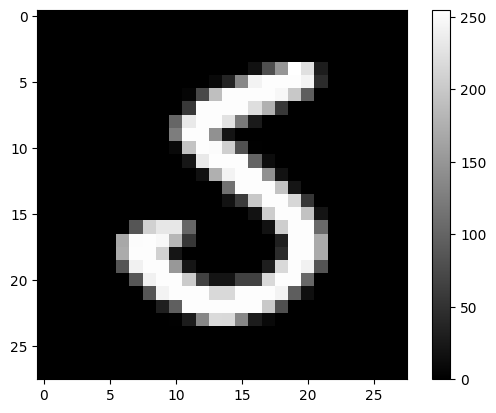

In [ ]:
plt.imshow(train_DS.data[138], cmap="gray")
plt.colorbar()

In [ ]:
print(train_DS.targets)
print(train_DS.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])


## DataLoader 구경

In [ ]:
BATCH_SIZE = 32
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
print(len(train_DL.dataset))


60000
<class 'torch.Tensor'>


<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor(4)
torch.uint8
torch.float32


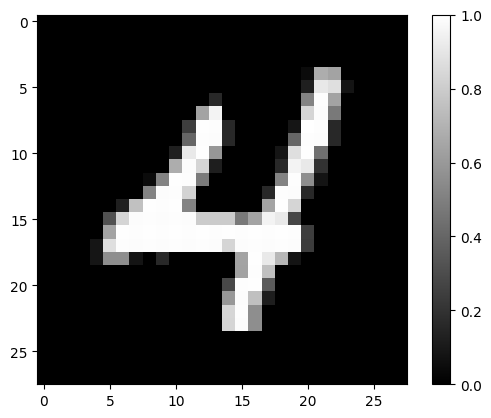

In [ ]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자
print(type(train_DS.data))
print(type(x_batch))
print(x_batch.shape)
print(y_batch.shape)
plt.imshow(x_batch[0].squeeze(), cmap="gray")
plt.colorbar()
print(y_batch[0])

print(train_DL.dataset.data.dtype)
print(x_batch.dtype)
# ToTensor 의 역할
# 1. tensor로 바꿔준다
# 2. 개채행열로 바꿔준다
# 3. 0~1 사이로 바꿔준다 (int -> float) - Normalization

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor(0)
torch.uint8
torch.float32


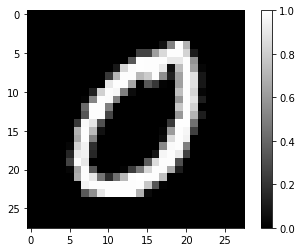

In [ ]:
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0][0][0][0])
x_batch, y_batch = next(iter(train_DL)) # next(iter(train_DS)) 는 한장만 꺼내기
print(type(x_batch))
print(x_batch.shape)
print(x_batch.dtype)
print(x_batch[0][0][0][0])

In [ ]:
x = torch.ones(2,2,3,3)
y = torch.zeros(2,2,3,3)
x[:,:,:,2] = y[:,:,:,2]
z = torch.flatten(x, start_dim=1)
z.shape

torch.Size([2, 18])

## 본격적으로 model 만들기!

In [ ]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(28*28, 100),
                                    nn.ReLU(),
                                    nn.Linear(100,10))

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

In [ ]:
# flatten 확인
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)
flat_images = torch.flatten(x_batch)
print(flat_images.shape)
flat_images2 = torch.flatten(x_batch, start_dim=1)
print(flat_images2.shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


In [ ]:
model = MLP()
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch).shape)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 10])


## 모델 훈련시키기!

In [ ]:
from re import L
from torch import optim

LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss() # Loss function
optimizer = optim.Adam(model.parameters(), lr=LR)
T_N = len(train_DL.dataset)

loss_history =[]
model.train() # train mode로 전환

for ep in range(EPOCH):
    rloss = 0 # running loss
    for x_batch, y_batch in train_DL:
        # inference
        y_hat = model(x_batch)
        # loss
        loss = criterion(y_hat, y_batch)
        #update
        optimizer.zero_grad() # gradient 누적 초기화
        loss.backward()
        optimizer.step() # weight update
        # loss accumulation
        loss_b = loss.item() *  x_batch.shape[0]
        rloss += loss_b

    # print loss
    # loss_history += [loss.item()]
    loss_e = rloss/T_N
    loss_history += [loss_e]
    # print(f"Epoch: {ep+1}, train loss: {round(loss.item(),3)}")
    print(f"Epoch: {ep+1}, train loss: {round(loss_e,3)}")
    print("-" * 20)

Epoch: 1, train loss: 0.308
--------------------
Epoch: 2, train loss: 0.14
--------------------
Epoch: 3, train loss: 0.097
--------------------
Epoch: 4, train loss: 0.074
--------------------
Epoch: 5, train loss: 0.058
--------------------


In [ ]:
len(train_DL.dataset)

60000

In [ ]:
from torch import optim

LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss() # Loss function

def Train(model, train_DL, criterion, optimizer):

    loss_history =[]
    NoT = len(train_DL.dataset)

    model.train() # train mode로 전환
    for ep in range(EPOCH):
        rloss = 0 # running loss
        for x_batch, y_batch in train_DL:
            x_batch = x_batch.to(DEVICE) # GPU 활용
            y_batch = y_batch.to(DEVICE) # GPU 활용
            # inference
            y_hat = model(x_batch)
            # loss
            loss = criterion(y_hat, y_batch)
            # update
            optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
            loss.backward() # backpropagation
            optimizer.step() # weight update
            # loss accumulation
            loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
            rloss += loss_b # running loss
        # print loss
        loss_e = rloss/NoT
        loss_history += [loss_e]
        print(f"Epoch: {ep+1}, train loss: {round(loss_e,3)}")
        print("-"*20)

    return loss_history

## Cross Entropy 확인 (왜 모델에 softmax를 안붙였을까?)



In [ ]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

y_hat = torch.randn(3, 5) # data는 세 개, 5 종류로 분류하는 문제 가정
print(y_hat) # 가로 축으로 합이 1이 아님, 즉, softmax 통과 전
# y_batch = torch.randint(5, (3,))
y_batch = torch.randint(5, (3,)) # 0~4 까지 수 중에 3개를 랜덤하게 생성
print(y_batch)

# 방법 1
loss = F.cross_entropy(y_hat, y_batch) # softmax가 내장
print(loss)

# 방법 2
criterion = nn.CrossEntropyLoss() # softmax가 내장
print(criterion(y_hat, y_batch))

# 방법 3
y_hat_soft = F.softmax(y_hat, dim=1)
print(y_hat_soft)
for i, val in enumerate(y_hat_soft) :
    print(i)
    print(val)
loss = 0
for i, val in enumerate(y_hat_soft):
    print(i, val)
    loss += -torch.log(val[y_batch[i]])
print(loss/len(y_hat_soft)) # 평균이 내장되어있음을 알 수 있다

tensor([[-0.5921,  0.2705, -0.7953,  0.8989, -0.5072],
        [ 1.8614,  0.0515,  0.9247,  1.5108, -1.3314],
        [-0.4963,  0.4912, -0.4087,  1.0687,  0.5027]])
tensor([3, 3, 0])
tensor(1.4914)
tensor(1.4914)
tensor([[0.1029, 0.2439, 0.0840, 0.4571, 0.1120],
        [0.4346, 0.0711, 0.1703, 0.3061, 0.0178],
        [0.0815, 0.2187, 0.0889, 0.3896, 0.2212]])
0
tensor([0.1029, 0.2439, 0.0840, 0.4571, 0.1120])
1
tensor([0.4346, 0.0711, 0.1703, 0.3061, 0.0178])
2
tensor([0.0815, 0.2187, 0.0889, 0.3896, 0.2212])
0 tensor([0.1029, 0.2439, 0.0840, 0.4571, 0.1120])
1 tensor([0.4346, 0.0711, 0.1703, 0.3061, 0.0178])
2 tensor([0.0815, 0.2187, 0.0889, 0.3896, 0.2212])
tensor(1.4914)


## 모델 학습시키기

Epoch: 1, train loss: 0.311
--------------------
Epoch: 2, train loss: 0.139
--------------------
Epoch: 3, train loss: 0.096
--------------------
Epoch: 4, train loss: 0.073
--------------------
Epoch: 5, train loss: 0.058
--------------------


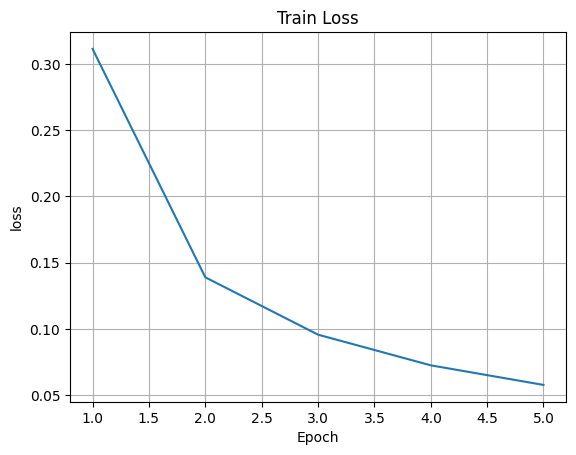

In [ ]:
model = MLP().to(DEVICE) # x_batch, y_batch, model 까지 DEVICE에 올려줘야 함
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
loss_history = Train(model, train_DL, criterion, optimizer)

plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title("Train Loss")
plt.grid()

## 모델 저장하기 & 불러오기

In [ ]:
save_model_path = "/content/drive/MyDrive/test_result/MLP_MNIST.pt"
# save_model_path = "/content/drive/MyDrive/Colab Notebooks/results/MLP_MNIST.pt"
torch.save(model.state_dict(), save_model_path)

In [ ]:
load_model = MLP().to(DEVICE)
load_model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))
# map_location 있어야 GPU로 학습했던 거 현재 device로 불러올 수 있음

<All keys matched successfully>

## 모델 테스트하기

In [ ]:
y_hat_soft = F.softmax(y_hat, dim=1)
y_hat_soft

tensor([[0.1029, 0.2439, 0.0840, 0.4571, 0.1120],
        [0.4346, 0.0711, 0.1703, 0.3061, 0.0178],
        [0.0815, 0.2187, 0.0889, 0.3896, 0.2212]])

In [ ]:
# def Test(model, test_DL):
#     model.eval()
#     with torch.no_grad():
#         rcorrect = 0
#         for x_batch, y_batch in test_DL:
#             x_batch = x_batch.to(DEVICE)
#             y_batch = y_batch.to(DEVICE)
#             # inference
#             y_hat = model(x_batch)

In [ ]:
def Test(model, test_DL):
    model.eval()
    with torch.no_grad():
        rcorrect = 0
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # accuracy accumulation
            pred = y_hat.argmax(dim=1)
            corrects_b = torch.sum(pred == y_batch).item()
            rcorrect += corrects_b
        accuracy_e = rcorrect/len(test_DL.dataset)*100
    print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({round(accuracy_e,1)} %)")

In [ ]:
Test(load_model, test_DL)

Test accuracy: 9737/10000 (97.4 %)


In [ ]:
def Test_plot(model, test_DL):
    model.eval()
    with torch.no_grad(): # model.eval()와 세트로 생각
        x_batch, y_batch = next(iter(test_DL))
        x_batch = x_batch.to(DEVICE)
        y_hat = model(x_batch)
        pred = y_hat.argmax(dim=1)

    x_batch = x_batch.to("cpu")

    plt.figure(figsize=(8,4))
    for idx in range(6):
        plt.subplot(2,3, idx+1, xticks=[], yticks=[]) # x/yticks를 [] 빈 리스트로 해야 눈금이 사라짐
        plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap="gray") # 차원을 채행렬을 행렬채로 변경
        pred_class = test_DL.dataset.classes[pred[idx]]
        true_class = test_DL.dataset.classes[y_batch[idx]]
        plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r")

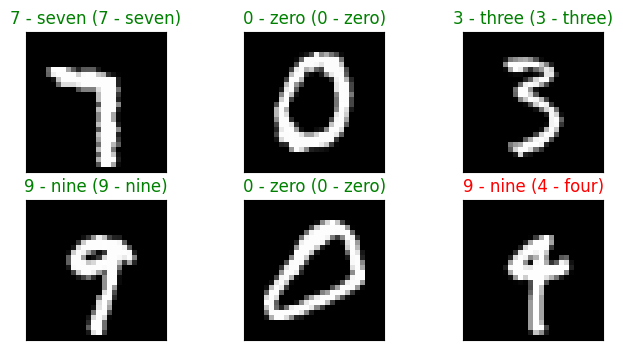

In [ ]:
Test_plot(load_model, test_DL)

In [ ]:
# 파라미터 수 구하기
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

In [ ]:
print(count_params(load_model))

79510
